# Modelos no Supervisados

In [1]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src.Routes import RUTAS
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from src.model_evaluation import evaluar_clusters
from src.model_training import entrenar_Kmeans


## Preparación y Escalado de los Datos

In [2]:
path_archivo_codificado = RUTAS['data_processed'] / 'Sales_Marketing_Clean_(Codificado).csv'

df = pd.read_csv(path_archivo_codificado)
df.head()

,age,total_spent,avg_order_value,lifetime_value,last_3_month_purchase_freq,marketing_spend_per_user,total_visits,avg_session_time,pages_per_session,email_open_rate,email_click_rate,support_tickets,delivery_delay_days,satisfaction_score,nps_score,gender,country,acquisition_channel,subscription_type,payment_method
0,35,559.525,65.247,915.311,14,27.56,7,13.904,5.415,0.67,0.26,0,3,3.0,10,1,2,0,0,4
1,35,356.491,48.474,2079.961,11,15.15,19,5.113,5.352,0.70,0.37,5,3,3.0,7,3,1,3,1,0
2,27,689.332,77.815,1379.151,9,13.51,18,9.743,3.595,0.47,0.44,1,2,5.0,6,0,1,0,0,4
3,36,445.430,71.712,774.653,7,25.65,16,9.643,2.950,0.58,0.37,0,2,4.0,6,0,2,1,0,2
4,29,686.286,44.990,87.680,11,12.39,12,7.791,2.406,0.05,0.16,2,4,3.0,1,1,5,4,1,0


Dado que el objetivo es segmentar comportamiento de clientes para marketing, se priorizan variables que capturan **valor económico**, **intensidad de uso** y **fricción de servicio**: gasto total, ticket promedio, frecuencia de compra, visitas, páginas por sesión y tickets de soporte.

Esta selección se toma sobre usar todo el dataset porque en clustering no supervisado las variables irrelevantes distorsionan distancias y pueden crear grupos artificiales. Al concentrarnos en señales de negocio accionables, los clústeres resultantes son más interpretables para decisiones comerciales.

In [3]:
cols_comportamiento = [
    'total_spent', 
    'avg_order_value', 
    'last_3_month_purchase_freq',
    'total_visits', 
    'pages_per_session', 
    'support_tickets'
]
X_cluster = df[cols_comportamiento]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)
print("Datos escalados correctamente. Dimensión:", X_scaled.shape)

Datos escalados correctamente. Dimensión: (15750, 6)


Primero se aíslan las variables de comportamiento porque K-Means opera con distancias geométricas y requiere una representación numérica consistente.

Luego se aplica `StandardScaler` para evitar que variables con mayor escala (por ejemplo, `total_spent`) dominen el cálculo de distancia sobre variables de menor rango (por ejemplo, `pages_per_session`). Esta acción se elige para que cada atributo aporte señal de forma comparable.

## Validación Matemática (Elbow Method y Silhouette Score)

probando K=2
Silouette Score: 0.1287
probando K=3
Silouette Score: 0.1216
probando K=4
Silouette Score: 0.1178
probando K=5
Silouette Score: 0.1163
probando K=6
Silouette Score: 0.1168


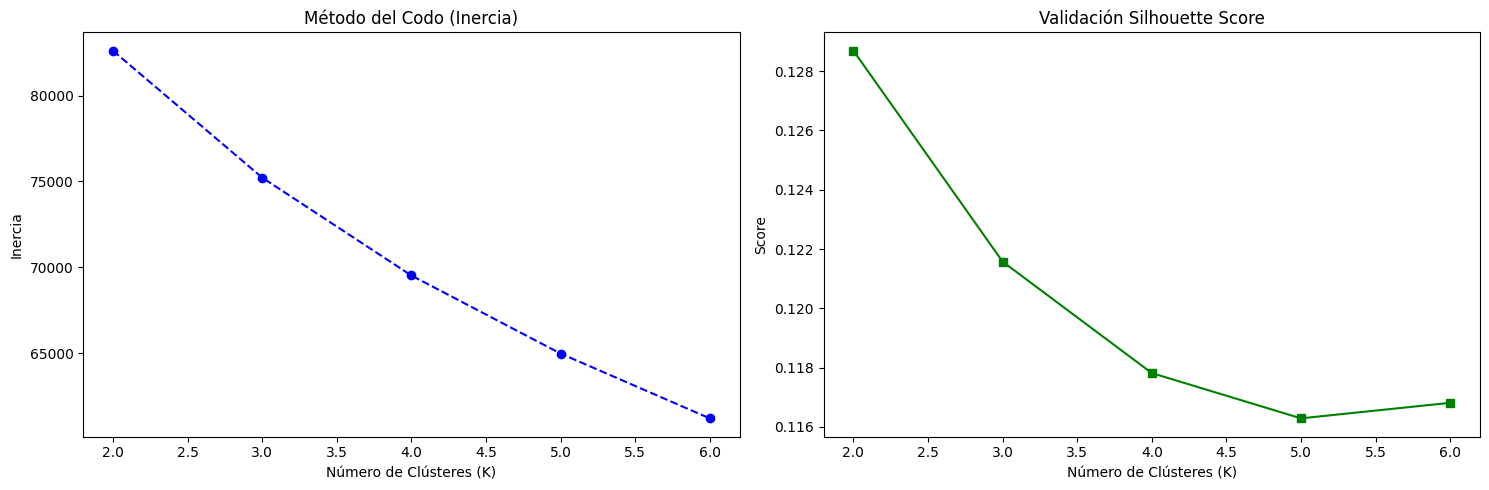

In [4]:
inercia = []
silhouette_scores = []
k_range = range(2,7)

for k in k_range:
    kmeans = entrenar_Kmeans(X_scaled,n_clusters=k)

    inercia.append(kmeans.inertia_)
    print(f'probando K={k}')
    score = evaluar_clusters(X_scaled, kmeans.labels_)
    silhouette_scores.append(score)
# Gráficos de validación
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico del Método del Codo
ax[0].plot(k_range, inercia, marker='o', linestyle='--', color='b')
ax[0].set_title('Método del Codo (Inercia)')
ax[0].set_xlabel('Número de Clústeres (K)')
ax[0].set_ylabel('Inercia')

# Gráfico de Silhouette Score
ax[1].plot(k_range, silhouette_scores, marker='s', linestyle='-', color='g')
ax[1].set_title('Validación Silhouette Score')
ax[1].set_xlabel('Número de Clústeres (K)')
ax[1].set_ylabel('Score')

plt.tight_layout()
plt.show()

El método del codo sugiere una mejora decreciente a partir de **K=4**, mientras que Silhouette favorece **K=2** por separación estadística más marcada. Sin embargo, para el objetivo comercial se selecciona **K=3** porque ofrece una segmentación más útil en términos operativos.

La decisión de usar K=3 sobre K=2 se justifica por accionabilidad: tres perfiles permiten diseñar estrategias diferenciadas (alto, medio y bajo compromiso) sin perder simplicidad de ejecución para campañas de retención y upselling.

## PERFILAMIENTO DE CLÚSTERES

In [5]:
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster_perfil'] = kmeans_final.fit_predict(X_scaled)

centroides = df.groupby('cluster_perfil')[cols_comportamiento].mean()

centroides['cantidad_clientes'] = df['cluster_perfil'].value_counts()

print("\n--- PERFILAMIENTO DE CLÚSTERES (CENTROIDES) ---")
display(centroides.round(2))


--- PERFILAMIENTO DE CLÚSTERES (CENTROIDES) ---


,total_spent,avg_order_value,last_3_month_purchase_freq,total_visits,pages_per_session,support_tickets,cantidad_clientes
cluster_perfil,,,,,,,
0,495.03,60.85,10.92,14.93,3.99,1.38,5982
1,516.48,60.40,7.04,14.90,4.06,3.89,3788
2,519.02,59.03,3.01,15.11,3.96,1.40,5980


El perfilamiento muestra que gasto y navegación son relativamente parecidos entre grupos, mientras que la **frecuencia de compra** es la variable que más separa los clústeres. Por eso, la lectura de negocio debe centrarse en recurrencia más que en ticket aislado.

Con base en los centroides, la segmentación operativa queda así:

- **Clúster 0 (Activos):** alta frecuencia de compra y flujo constante.
- **Clúster 1 (Regulares):** comportamiento intermedio y potencial de crecimiento.
- **Clúster 2 (Esporádicos/En riesgo):** baja frecuencia, pero buen gasto cuando compran.

Esta clasificación se elige porque permite priorizar acciones concretas por grupo, en lugar de aplicar una estrategia uniforme a toda la base.

**Nota:** El equipo de marketing debería enfocarse en el Clúster 2. Entran a la página igual que los demás (15 visitas), gastan bien cuando compran, pero lo hacen muy poco. Aquí hay una oportunidad de retención.

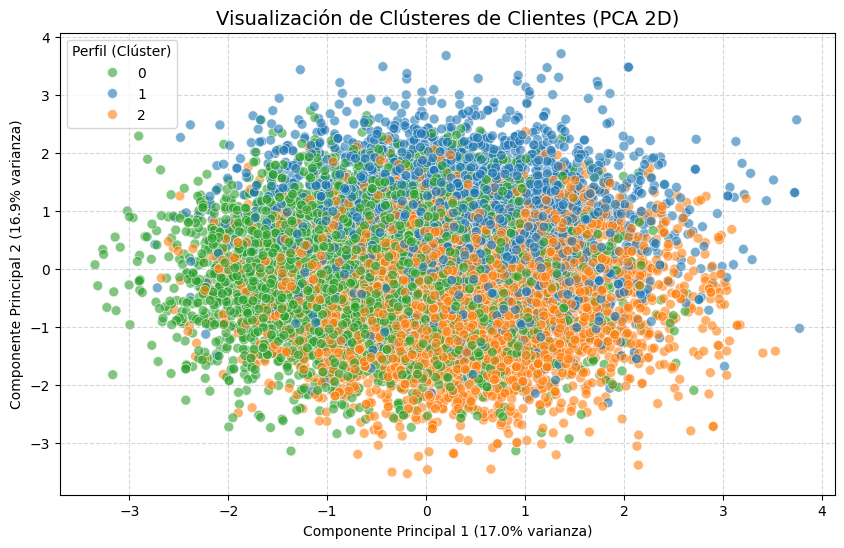

In [6]:
from sklearn.decomposition import PCA
import seaborn as sns

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(data=X_pca, columns=['Componente_1', 'Componente_2'])
df_pca['Cluster'] = df['cluster_perfil'].astype(str)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='Componente_1', 
    y='Componente_2', 
    hue='Cluster', 
    data=df_pca, 
    palette=['#2ca02c','#1f77b4', '#ff7f0e'], # Colores diferenciados
    alpha=0.6,
    s=50
)

plt.title('Visualización de Clústeres de Clientes (PCA 2D)', fontsize=14)
plt.xlabel(f'Componente Principal 1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza)')
plt.ylabel(f'Componente Principal 2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza)')
plt.legend(title='Perfil (Clúster)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Para visualizar los perfiles se aplica **PCA** y se proyectan los clientes en dos componentes. Esta acción se toma para comunicar hallazgos de forma clara al negocio, aun sabiendo que la proyección reduce información del espacio original.

El gráfico evidencia transición gradual entre perfiles (sin fronteras rígidas), lo que sugiere que pequeños estímulos comerciales pueden mover clientes entre segmentos. Al mismo tiempo, la varianza explicada en 2D es limitada, por lo que la interpretación visual debe complementarse con métricas del espacio original.

En síntesis, se elige PCA como herramienta de comunicación y exploración, no como sustituto de la validación cuantitativa del clustering.

# Modelos Supervisados

In [7]:
import pandas as pd
import numpy as np
import sys
sys.path.append('../src')
from src.model_training import construir_pipeline_clasificacion
from sklearn.model_selection import train_test_split

### Carga de datos

In [8]:
path_archivo_codificado = RUTAS['data_processed'] / 'Sales_Marketing_Clean_(Codificado).csv'

df_cod = pd.read_csv(path_archivo_codificado)
df_cod.head()

,age,total_spent,avg_order_value,lifetime_value,last_3_month_purchase_freq,marketing_spend_per_user,total_visits,avg_session_time,pages_per_session,email_open_rate,email_click_rate,support_tickets,delivery_delay_days,satisfaction_score,nps_score,gender,country,acquisition_channel,subscription_type,payment_method
0,35,559.525,65.247,915.311,14,27.56,7,13.904,5.415,0.67,0.26,0,3,3.0,10,1,2,0,0,4
1,35,356.491,48.474,2079.961,11,15.15,19,5.113,5.352,0.70,0.37,5,3,3.0,7,3,1,3,1,0
2,27,689.332,77.815,1379.151,9,13.51,18,9.743,3.595,0.47,0.44,1,2,5.0,6,0,1,0,0,4
3,36,445.430,71.712,774.653,7,25.65,16,9.643,2.950,0.58,0.37,0,2,4.0,6,0,2,1,0,2
4,29,686.286,44.990,87.680,11,12.39,12,7.791,2.406,0.05,0.16,2,4,3.0,1,1,5,4,1,0


### Entrenamiento de modelos

In [9]:
nombre_target = 'subscription_type'
y = df_cod[nombre_target]
X = df_cod.drop(columns=[nombre_target], errors='ignore')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Entrenando modelo Random Forest...')
pipeline_rf = construir_pipeline_clasificacion(tipo_de_modelo='rf')
pipeline_rf.fit(X_train, y_train)

print('Entrenando modelo Regresión Logistica...')
pipeline_lr = construir_pipeline_clasificacion(tipo_de_modelo='lr')
pipeline_lr.fit(X_train, y_train)

print('Modelos entrenados exitosamente')

Entrenando modelo Random Forest...
Entrenando modelo Regresión Logistica...
Modelos entrenados exitosamente


### Simulación de Campaña de Upselling

#### Simulación de campaña utilizando Random Forest

In [10]:
clientes_basicos_X = X_test[y_test == 0]

probabilidades_anuales = pipeline_rf.predict_proba(clientes_basicos_X)[:,1]

df_upselling = clientes_basicos_X.copy()
df_upselling['Probabilidad_upgrade'] = probabilidades_anuales

umbral = 0.75
clientes_objetivo = df_upselling[df_upselling['Probabilidad_upgrade'] >= umbral]

print(f"Total de clientes básicos analizados: {len(clientes_basicos_X)}")
print(f"Clientes identificados con alta probabilidad de Upgrade (>75%): {len(clientes_objetivo)}")

display(clientes_objetivo.head())

Total de clientes básicos analizados: 1544
Clientes identificados con alta probabilidad de Upgrade (>75%): 1


,age,total_spent,avg_order_value,lifetime_value,last_3_month_purchase_freq,marketing_spend_per_user,total_visits,avg_session_time,pages_per_session,email_open_rate,email_click_rate,support_tickets,delivery_delay_days,satisfaction_score,nps_score,gender,country,acquisition_channel,payment_method,Probabilidad_upgrade
12223,31,64.891,53.925,1203.906,12,21.08,16,10.217,4.061,0.18,0.32,2,3,2.0,1,3,2,0,2,0.75


#### Simulación de campaña utilizando Regresión Logística

In [11]:
probabilidades_anuales_lr = pipeline_lr.predict_proba(clientes_basicos_X)[:, 1]

df_upselling_lr = clientes_basicos_X.copy()
df_upselling_lr['Probabilidad_upgrade_LR'] = probabilidades_anuales_lr

umbral = 0.75
clientes_objetivo_lr = df_upselling_lr[df_upselling_lr['Probabilidad_upgrade_LR'] >= umbral]

print(f"Total de clientes básicos analizados: {len(clientes_basicos_X)}")
print(f"Clientes identificados por Regresión Logística con alta probabilidad de Upgrade (>75%): {len(clientes_objetivo_lr)}")

display(clientes_objetivo_lr.head())

Total de clientes básicos analizados: 1544
Clientes identificados por Regresión Logística con alta probabilidad de Upgrade (>75%): 0


,age,total_spent,avg_order_value,lifetime_value,last_3_month_purchase_freq,marketing_spend_per_user,total_visits,avg_session_time,pages_per_session,email_open_rate,email_click_rate,support_tickets,delivery_delay_days,satisfaction_score,nps_score,gender,country,acquisition_channel,payment_method,Probabilidad_upgrade_LR


En la simulación inicial de upselling con umbral alto (0.75), **Random Forest** identifica al menos un caso con alta probabilidad de upgrade, mientras que **Regresión Logística** no detecta candidatos. Este comportamiento indica que el patrón de conversión no está siendo capturado adecuadamente por una frontera lineal.

Por este motivo se prioriza **Random Forest** sobre Regresión Logística para la siguiente fase: el modelo de árboles captura mejor no linealidades e interacciones entre variables de comportamiento. La regresión logística se mantiene como benchmark para control metodológico.

La acción elegida no es reducir inmediatamente el umbral, sino pasar primero a evaluación técnica (ROC-AUC, precision, recall y matriz de confusión) y tuning de hiperparámetros. Esta secuencia evita decisiones prematuras y permite ajustar el modelo con evidencia antes de escalar campañas comerciales.